<a href="https://colab.research.google.com/github/Oizys9/UTS_Visi_Komputer/blob/main/M_Faizal_Zhafran_Farros_Segmentasi_Sel_darah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving BCCD_Dataset-master.zip to BCCD_Dataset-master.zip


100%|██████████| 364/364 [00:01<00:00, 327.75it/s]


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 948ms/step - accuracy: 0.2621 - loss: 1.8740 - val_accuracy: 0.2877 - val_loss: 1.3663
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 619ms/step - accuracy: 0.3972 - loss: 1.4727 - val_accuracy: 0.4247 - val_loss: 1.0588
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 684ms/step - accuracy: 0.5301 - loss: 1.1527 - val_accuracy: 0.5753 - val_loss: 0.8703
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 783ms/step - accuracy: 0.6098 - loss: 0.9060 - val_accuracy: 0.6986 - val_loss: 0.7768
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 714ms/step - accuracy: 0.7117 - loss: 0.7570 - val_accuracy: 0.7123 - val_loss: 0.7403
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 653ms/step - accuracy: 0.6839 - loss: 0.8887 - val_accuracy: 0.7260 - val_loss: 0.7289
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 695ms/step - accuracy: 0.6992 - loss: 0.9143 - val_accuracy: 0.7397 - val_loss: 0.7269
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 517ms/step - accuracy: 0.7650 - loss: 0.7818 - val_accuracy: 0

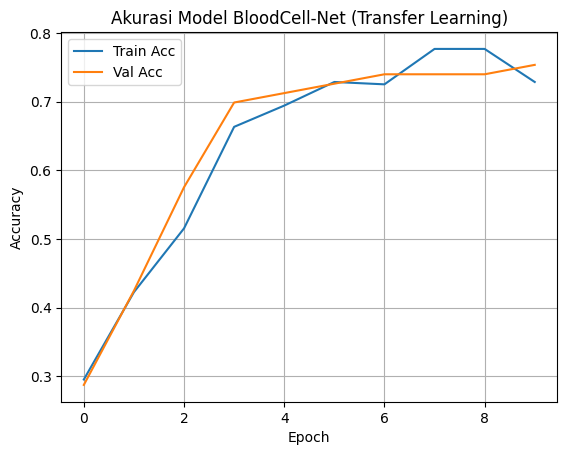

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: ['RBC']


In [1]:
# 1. Import Library
import os
import zipfile
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import xml.etree.ElementTree as ET
from google.colab import files

# 2. Upload ZIP Dataset
uploaded = files.upload()  # Upload file BCCD_Dataset-master.zip

# 3. Ekstrak ZIP
with zipfile.ZipFile('BCCD_Dataset-master.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# 4. Load dan preprocess gambar
IMG_SIZE = 128  # mobile-friendly, kecil tapi cukup informatif
image_dir = '/content/BCCD_Dataset-master/BCCD/JPEGImages/'
annotation_dir = '/content/BCCD_Dataset-master/BCCD/Annotations/'

data = []
labels = []

def extract_label_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    label_list = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        label_list.append(label)
    return label_list

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".jpg"):
        img_path = os.path.join(image_dir, fname)
        xml_path = os.path.join(annotation_dir, fname.replace('.jpg', '.xml'))

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            labels_found = extract_label_from_xml(xml_path)
            if labels_found:
                data.append(img)
                labels.append(labels_found[0])  # ambil label pertama saja
        except:
            continue

X = np.array(data)
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))

# 5. Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Augmentasi Data
train_aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_aug = ImageDataGenerator()  # no augment on validation

# 7. Load MobileNetV2 Pretrained Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze dulu

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(y.shape[1], activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# 8. Train Model
history = model.fit(
    train_aug.flow(X_train, y_train, batch_size=32),
    validation_data=val_aug.flow(X_val, y_val),
    epochs=10
)

# 9. Visualisasi Akurasi
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Akurasi Model BloodCell-Net (Transfer Learning)")
plt.grid(True)
plt.show()

# 10. Uji Prediksi
sample = X_val[0]
pred = model.predict(np.expand_dims(sample, axis=0))
print("Predicted:", le.inverse_transform([np.argmax(pred)]))
